# Regime-Shift: Macro-Aware Tactical Asset Allocation Engine

## Data ingestion

- yfinance - multi-asset daily returns
- FRED API - macro indicators (CPI yields spreads)
- CBOE VIX historical data

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from regime_shift import data_ingestion, regime_detection, optimizer, backtest, metrics, synthetic_data

pd.set_option("display.precision", 4) #table sizes
plt.rcParams["figure.figsize"] = (11, 4)
print ('over')

over


In [2]:
USE_LIVE_DATA = False
FRED_API_KEY = None  # set your key here 

if USE_LIVE_DATA:
    prices = data_ingestion.fetch_asset_prices(start="2005-01-01")
    vix = data_ingestion.fetch_vix(start="2005-01-01")
    macro = data_ingestion.fetch_macro(FRED_API_KEY, start="2005-01-01") if FRED_API_KEY else None
    features = data_ingestion.build_feature_frame(prices, vix, macro)
    asset_returns = data_ingestion.build_asset_return_frame(prices)
else:
    print("USE_LIVE_DATA=False -> using synthetic regime-switching data for a reproducible demo run.")
    features, asset_returns = synthetic_data.generate_synthetic_market(n_days=1500)

print(features.shape, asset_returns.shape)
features.head()

USE_LIVE_DATA=False -> using synthetic regime-switching data for a reproducible demo run.
(1481, 3) (1500, 3)


,return,vol_20d,vix
2018-01-26,0.0089,0.0070,12.0
2018-01-29,-0.0004,0.0070,12.0
2018-01-30,0.0115,0.0075,12.0
2018-01-31,-0.0047,0.0074,12.0
2018-02-01,0.0034,0.0075,12.0


## HMM regime detection

In [3]:
model, regimes= regime_detection.fit_and_decode(features)
label_map= regime_detection.label_map_by_mean_return(model, features)

print("Regime day counts:")
print(regimes.value_counts())
print()
print("Transition matrix:")
regime_detection.transition_matrix_report(model, label_map)

Regime day counts:
regime
Bear      1340
Crisis     125
Bull        16
Name: count, dtype: int64

Transition matrix:


,Bear,Crisis,Bull
Bear,9.9851e-01,3.9321e-21,0.0015
Crisis,1.6000e-02,9.6800e-01,0.0160
Bull,3.0605e-47,2.5000e-01,0.7500


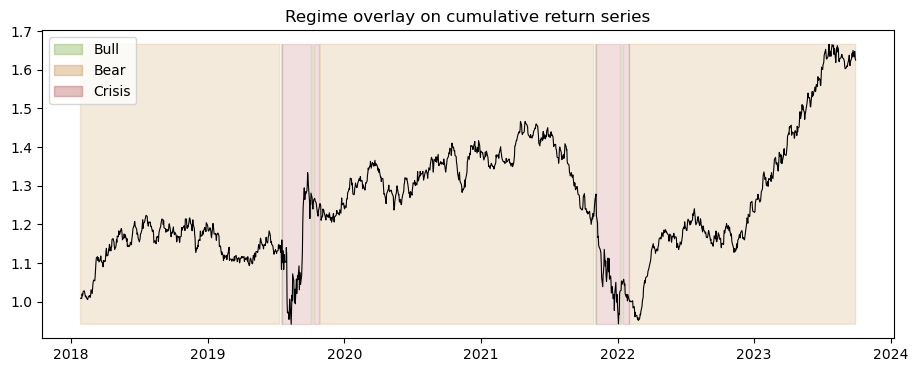

In [4]:
fig, ax= plt.subplots()
colors= {"Bull": "#639922", "Bear": "#BA7517", "Crisis": "#A32D2D"}
price_proxy= (1 + features["return"]).cumprod()
ax.plot(price_proxy.index, price_proxy.values, color="black", linewidth=0.8)
for regime, color in colors.items():
    mask=regimes==regime
    ax.fill_between(price_proxy.index, price_proxy.min(), price_proxy.max(),
                     where=mask.values, color=color, alpha=0.15, step="mid")
ax.set_title("Regime overlay on cumulative return series")
ax.legend(handles=[plt.Rectangle((0,0),1,1, color=c, alpha=0.3) for c in colors.values()],
          labels=colors.keys(), loc="upper left")
plt.show()

## Dynamic constraint mapping (CVXPY)

The optimizer's objective changes by regime:
- Bull- maximize expected return minus a penalty with low risk aversion
- Bear- same objective, higher risk aversion
- Crisis- minimize variance only 

In [5]:
mu, sigma = optimizer.estimate_moments(asset_returns)
for regime in ["Bull", "Bear", "Crisis"]:
    w = optimizer.solve_portfolio(mu, sigma, regime)
    print(regime, dict(zip(asset_returns.columns, w.round(3))))

Bull {'SPY': np.float64(0.272), 'TLT': np.float64(0.0), 'GLD': np.float64(0.728)}
Bear {'SPY': np.float64(0.217), 'TLT': np.float64(0.0), 'GLD': np.float64(0.783)}
Crisis {'SPY': np.float64(0.114), 'TLT': np.float64(0.445), 'GLD': np.float64(0.441)}


## Backtest

In [6]:
result = backtest.walk_forward_backtest(features, asset_returns, rebalance_freq="ME", train_window=252, min_train_size=150, friction_bps=7.5,)
result[["regime", "turnover", "cost", "gross_return", "net_return"]].head(10)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

,regime,turnover,cost,gross_return,net_return
date,,,,,
2018-08-31,Bear,1.0000e+00,7.5000e-04,-0.0170,-0.0177
2018-10-31,Bull,3.5611e-22,2.6708e-25,-0.0542,-0.0542
2018-11-30,Bull,2.6361e-22,1.9771e-25,0.0620,0.0620
2018-12-31,Bear,9.1879e-01,6.8909e-04,0.0012,0.0005
2019-01-31,Bull,1.0812e+00,8.1091e-04,0.0206,0.0198
2019-02-28,Bull,2.7736e-22,2.0802e-25,0.0968,0.0968
2019-04-30,Bear,4.4377e-22,3.3283e-25,-0.0217,-0.0217
2019-05-31,Bull,2.2269e-22,1.6701e-25,-0.0836,-0.0836
2019-07-31,Bear,2.2990e-22,1.7242e-25,0.0364,0.0364


,regime,turnover,cost,gross_return,net_return
date,,,,,
2018-08-31,Bear,1.0000e+00,7.5000e-04,-0.0170,-0.0177
2018-10-31,Bull,3.5611e-22,2.6708e-25,-0.0542,-0.0542
2018-11-30,Bull,2.6361e-22,1.9771e-25,0.0620,0.0620
2018-12-31,Bear,9.1879e-01,6.8909e-04,0.0012,0.0005
2019-01-31,Bull,1.0812e+00,8.1091e-04,0.0206,0.0198
2019-02-28,Bull,1.6634e-22,1.2475e-25,0.0968,0.0968
2019-04-30,Bear,3.3275e-22,2.4956e-25,-0.0217,-0.0217
2019-05-31,Bull,3.1428e-22,2.3571e-25,-0.0836,-0.0836
2019-07-31,Bear,1.0608e-23,7.9559e-27,0.0364,0.0364


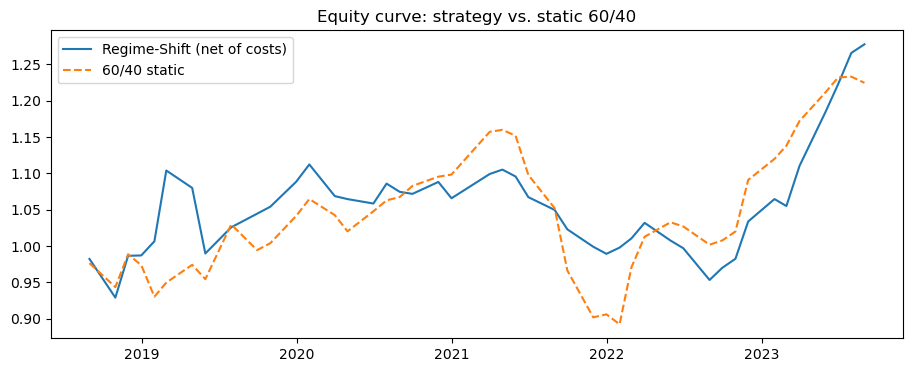

In [7]:
curve = backtest.equity_curve(result)
bench_6040 = backtest.static_benchmark_returns(asset_returns, {"SPY": 0.6, "TLT": 0.4}, rebalance_freq="ME")
bench_curve = (1 + bench_6040.reindex(result.index)).cumprod()

fig, ax = plt.subplots()
ax.plot(curve.index, curve.values, label="Regime-Shift (net of costs)")
ax.plot(bench_curve.index, bench_curve.values, label="60/40 static", linestyle="--")
ax.set_title("Equity curve: strategy vs. static 60/40")
ax.legend()
plt.show()

## Performance tear sheet

In [8]:
benchmarks = {
    "60/40 Static": bench_6040,
    "Equal-Weight Static": backtest.static_benchmark_returns(
        asset_returns, {c: 1/len(asset_returns.columns) for c in asset_returns.columns}, rebalance_freq="ME"),
}

sheet = metrics.tear_sheet(result["net_return"], benchmarks, turnover=result["turnover"], freq="M")
sheet

,Ann. Return,Sharpe,Sortino,Max Drawdown,Calmar,Avg Turnover,Total Cost Drag
Series,,,,,,,
Regime-Shift (strategy),0.0676,0.6213,1.0538,-0.1430,0.4725,0.6095,0.0
60/40 Static,0.0835,0.7091,1.2155,-0.2308,0.3619,NaN,NaN
Equal-Weight Static,0.0904,1.0108,2.0827,-0.1269,0.7126,NaN,NaN
